# **IMPORT PACKAGES**

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import os

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


# **EDA**

In [24]:
path = os.listdir(r'train')
classes = {'Normal':0, 'Lung cancer':1}

# **TRAINING DATASET**

In [25]:
import cv2
X = []
Y = []
for cls in classes:
    path = 'train/'+cls
    for j in os.listdir(path):
        img = cv2.imread(path+'/'+j, 0)
        img = cv2.resize(img, (200,200))
        X.append(img)
        Y.append(classes[cls])
X = np.array(X)
Y = np.array(Y)

((492, 40000), (123, 40000))

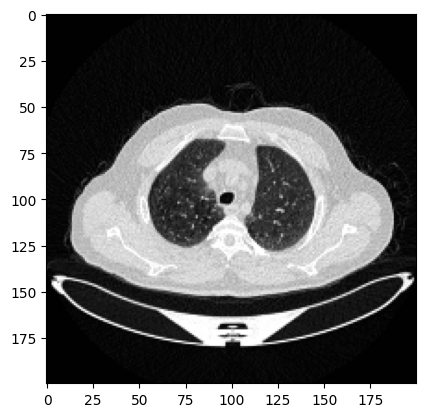

In [26]:
X_updated = X.reshape(len(X), -1)
np.unique(Y)
pd.Series(Y).value_counts()
X.shape, X_updated.shape
plt.imshow(X[0], cmap='gray')
X_updated = X.reshape(len(X), -1)
X_updated.shape
xtrain, xtest, ytrain, ytest = train_test_split(X_updated, Y, random_state=10, test_size=.20)
xtrain.shape, xtest.shape

In [27]:
print(xtrain.max(), xtrain.min())
print(xtest.max(), xtest.min())
xtrain = xtrain/255
xtest = xtest/255
print(xtrain.max(), xtrain.min())
print(xtest.max(), xtest.min())

255 0
255 0
1.0 0.0
1.0 0.0


In [28]:
from sklearn.decomposition import PCA

print(xtrain.shape, xtest.shape)

pca = PCA(.98)
# pca_train = pca.fit_transform(xtrain)
# pca_test = pca.transform(xtest)
pca_train = xtrain
pca_test = xtest

(492, 40000) (123, 40000)


# Ignore warnings

In [29]:
import warnings
warnings.filterwarnings('ignore')

# Initialize and train logistic regression model

In [30]:
from sklearn.ensemble import VotingClassifier
lg = LogisticRegression(C=0.1)

sv = SVC()
cmodel=VotingClassifier(estimators=[('lr',lg),('SVM',sv)],voting='hard')

cmodel.fit(xtrain,ytrain)


VotingClassifier(estimators=[('lr', LogisticRegression(C=0.1)), ('SVM', SVC())])

In [31]:
import joblib

joblib.dump(cmodel,'CModel.pkl')



['CModel.pkl']

In [32]:
print("Testing Score:", cmodel.score(xtest, ytest))

Testing Score: 0.991869918699187


# Make predictions using support vector machine model

In [33]:
pred = cmodel.predict(xtest)

# Find misclassified samples

In [34]:
misclassified = np.where(ytest != pred)

# Print total misclassified samples

In [35]:
print("\nTotal Misclassified Samples: ", len(misclassified[0]))
print("Prediction for the 36th sample:", pred[36])
print("Actual label for the 36th sample:", ytest[36])


Total Misclassified Samples:  1
Prediction for the 36th sample: 1
Actual label for the 36th sample: 1


# Define a dictionary for decoding labels

In [36]:
dec = {0: 'Normal', 1: 'Lung cancer'}

# Plotting 1

In [37]:
plt.figure(figsize=(12, 8))
p = os.listdir(r'Testing')
c = 1

<Figure size 1200x800 with 0 Axes>

# Visualizing Predictions on Normal  Images

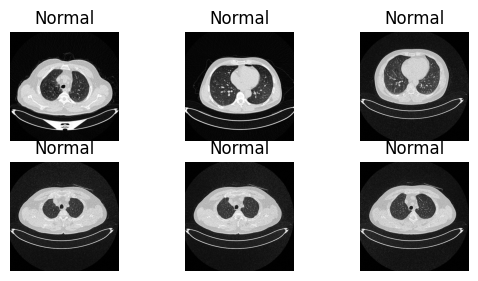

In [38]:
for i in os.listdir(r'Testing/Normal/')[:6]:
    plt.subplot(3,3,c)

    img = cv2.imread(r'Testing/Normal/'+i,0)
    img1 = cv2.resize(img, (200,200))
    img1 = img1.reshape(1,-1)/255
    p = cmodel.predict(img1)
    plt.title(dec[p[0]])
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1

# Plotting 2

In [39]:
plt.figure(figsize=(12,8))
p = os.listdir(r'Testing/')
c=1


<Figure size 1200x800 with 0 Axes>

# Visualizing Predictions on Cancer Images

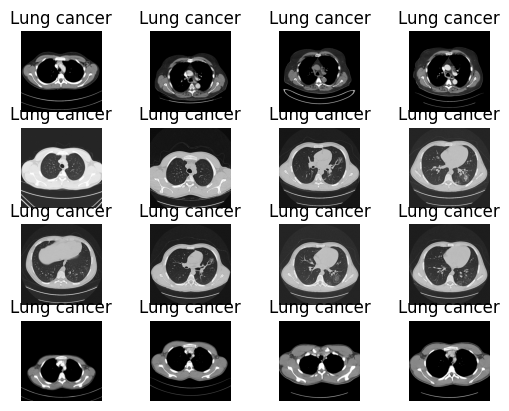

In [40]:
for i in os.listdir(r'Testing/Lung cancer/')[:16]:
    plt.subplot(4,4,c)

    img = cv2.imread(r'Testing/Lung cancer/'+i,0)
    img1 = cv2.resize(img, (200,200))
    img1 = img1.reshape(1,-1)/255
    p = cmodel.predict(img1)
    plt.title(dec[p[0]])
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1


# **FINDING FOR NEW IMAGE**

In [41]:
def classify_single_image(image_path):
    model=joblib.load("CModel.pkl")
    img = cv2.imread(image_path, 0)
    img = cv2.resize(img, (200, 200))
    img_processed = img.reshape(1, -1) / 255
    prediction = model.predict(img_processed)
    if prediction[0] == 0:
        return 'Normal'
    else:
        return 'Lung cancer'

In [42]:
image_path = r'Testing\Normal\Normal case (3).jpg'
prediction = classify_single_image(image_path)
print("Prediction for", image_path, ":", prediction)

Prediction for Testing\Normal\Normal case (3).jpg : Normal
